# Exploratory data analysis (EDA) and feature engineering

Before fitting any classifier, it helps to understand the data: what the features look like, how well they separate the three species, and whether anything needs to be fixed before modeling.

In this notebook we will:

* Load the Iris dataset and run basic sanity checks (shape, types, missing values, duplicates, class balance).
* Look at the distribution of each measurement, split by species.
* Look at how the four measurements relate to each other.
* Derive a small set of engineered features (areas and ratios) that may help models beyond the four raw measurements.
* Scale the features and project them into two dimensions, for later visualization.
* Save the processed dataset and feature matrix used by the modeling notebook.

## Dataset description

The dataset contains one row per flower, with four continuous measurements (in centimeters) and a species label:

| Feature | Description |
| --- | --- |
| `sepal_length` | Length of the sepal, in centimeters. |
| `sepal_width` | Width of the sepal, in centimeters. |
| `petal_length` | Length of the petal, in centimeters. |
| `petal_width` | Width of the petal, in centimeters. |
| `species` | Target variable. One of `Iris-setosa`, `Iris-versicolor`, or `Iris-virginica`. |

There are 150 rows total, 50 per species, with no missing values. This is one of the cleanest datasets commonly used for classification, so most of the work here is in understanding the features rather than cleaning them.

## Imports

First, we import the libraries used throughout the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Load data

The raw CSV is the only input file. We load it and take a first look at its contents.

In [2]:
raw = pd.read_csv("../data/raw/IRIS.csv")
raw.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Sanity checks

Before any visualization, we check the basic shape and quality of the data: how many rows and columns, whether the types are as expected, whether any values are missing, whether any rows are exact duplicates, and whether the three species are balanced.

In [3]:
print("Shape:", raw.shape)
print()
print("Dtypes:")
print(raw.dtypes)
print()
print("Missing values:")
print(raw.isna().sum())
print()
print("Duplicate rows:", raw.duplicated().sum())
print()
print("Class balance:")
print(raw["species"].value_counts())

Shape: (150, 5)

Dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 3

Class balance:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


The dataset is exactly as expected: 150 rows, four numeric measurements plus the species label, no missing values, and a perfectly balanced 50/50/50 split across species. Balanced classes mean plain accuracy is a reasonable metric here, and we do not need class-weighting strategies during modeling.

The one finding worth a second look is the three duplicate rows. Checking them individually shows that they are legitimate repeated measurements, not conflicting labels: the same combination of the four measurements appears more than once, always for the same species. This is plausible for a small dataset measured at a coarse precision, where distinct flowers can share identical rounded measurements. We keep them: they represent real, distinct observations rather than an artifact of the data pipeline, and dropping them would only shrink two of the three already-small classes.

## Univariate analysis

We start simple: for each of the four measurements, how does its distribution differ across species? A boxplot per feature, split by species, gives a quick view of both the typical value and the spread within each species.

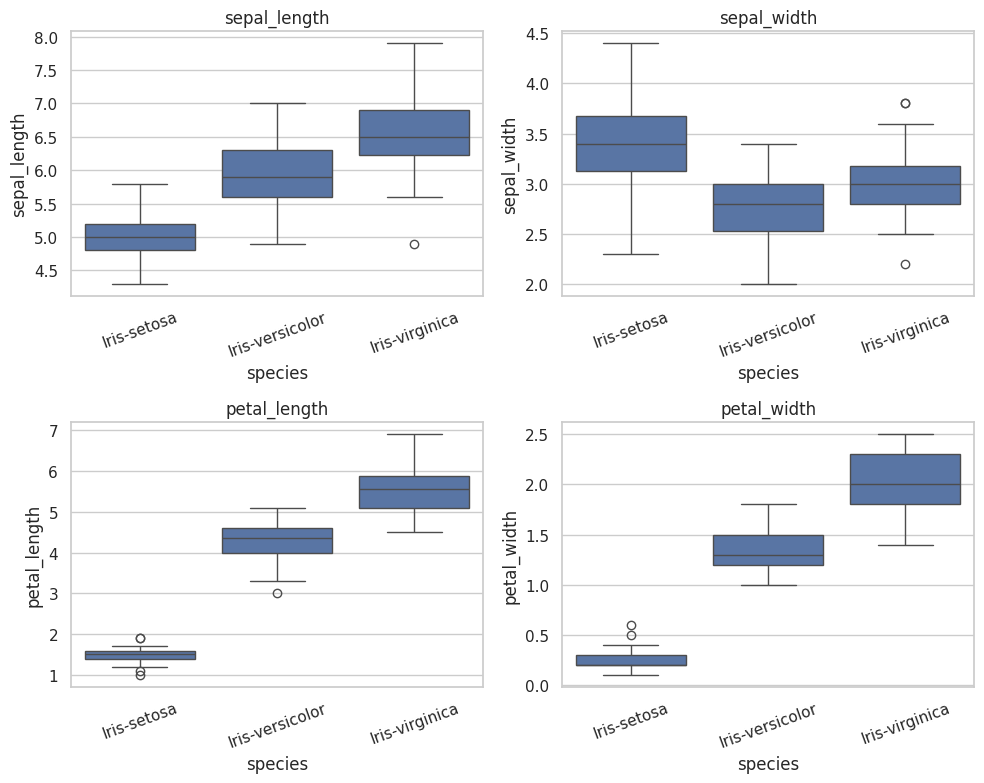

In [4]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(data=raw, x="species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()

`Iris-setosa` stands apart from the other two species on every feature, most dramatically on petal length and petal width, where its values barely overlap with the other two species at all. `Iris-versicolor` and `Iris-virginica` are harder to tell apart: their sepal width distributions overlap almost completely, and even petal length and petal width, the most informative features, show a range where the two species overlap.

This already tells us most of what to expect from any classifier: separating setosa from the other two should be close to trivial, while distinguishing versicolor from virginica is where the real difficulty lies.

## Bivariate analysis

Looking at one feature at a time hides relationships between features. A pairplot shows every pair of measurements at once, and a correlation matrix summarizes the strength of those relationships numerically.

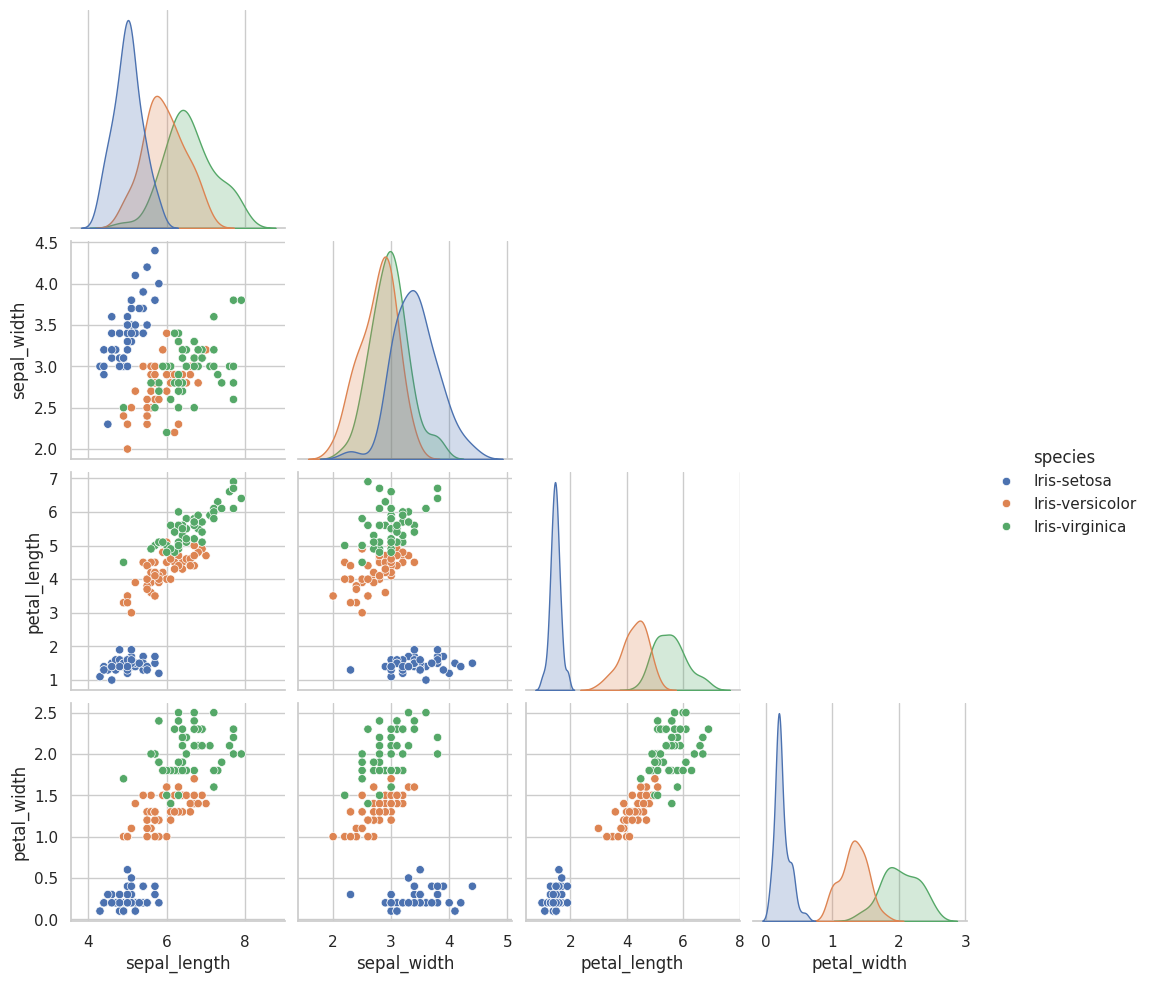

In [5]:
sns.pairplot(raw, hue="species", corner=True)

The pairplot confirms the univariate story and adds detail: setosa forms a tight, well-separated cluster in every pairwise view, especially any plot involving petal length or petal width. Versicolor and virginica form two clusters that are visibly distinct but adjacent, with the most overlap on sepal width against any other feature, and the least overlap on petal length against petal width, where the two species are almost, but not entirely, separable by a straight line.

Text(0.5, 1.0, 'Feature correlation')

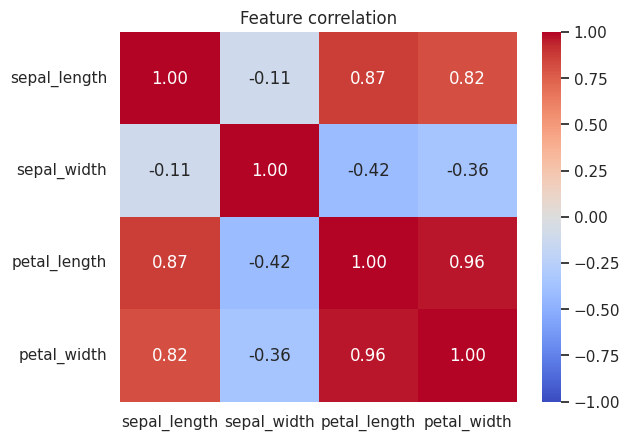

In [6]:
corr = raw[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature correlation")

The correlation matrix quantifies this. `petal_length` and `petal_width` are almost perfectly correlated with each other and both correlate strongly with `sepal_length`. `sepal_width` is the odd one out: it is only weakly correlated with the other three features, which matches its comparatively poor ability to separate the species. This strong correlation between the petal measurements will resurface later: two highly correlated features are somewhat redundant, but for tree-based and margin-based classifiers this redundancy is rarely a problem, unlike with a plain linear model, where multicollinearity can affect coefficient stability.

Combining both views: setosa is essentially solved by any reasonable model, and the versicolor/virginica boundary, mostly visible in the petal measurements, is the main source of classification error to watch for in the modeling notebook.

## Feature engineering

The four raw measurements are already clean and already carry most of the signal, as the plots above show. Feature engineering here does not fix data problems; it adds a handful of derived measurements that summarize the raw ones differently and may make the versicolor/virginica boundary easier for some models to find:

* `sepal_area` and `petal_area` (length times width) approximate the two-dimensional size of each organ, rather than treating length and width as independent.
* `petal_sepal_length_ratio` and `petal_sepal_width_ratio` capture the proportions of petal to sepal, which may vary by species independently of overall flower size.

These are simple, interpretable transformations rather than an exhaustive search over feature combinations, in keeping with a dataset this small and this clean.

In [7]:
data = raw.copy()

data["sepal_area"] = data["sepal_length"] * data["sepal_width"]
data["petal_area"] = data["petal_length"] * data["petal_width"]
data["petal_sepal_length_ratio"] = data["petal_length"] / data["sepal_length"]
data["petal_sepal_width_ratio"] = data["petal_width"] / data["sepal_width"]

data.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area,petal_area,petal_sepal_length_ratio,petal_sepal_width_ratio
0,5.1,3.5,1.4,0.2,Iris-setosa,17.85,0.28,0.274510,0.057143
1,4.9,3.0,1.4,0.2,Iris-setosa,14.70,0.28,0.285714,0.066667
2,4.7,3.2,1.3,0.2,Iris-setosa,15.04,0.26,0.276596,0.062500
3,4.6,3.1,1.5,0.2,Iris-setosa,14.26,0.30,0.326087,0.064516
4,5.0,3.6,1.4,0.2,Iris-setosa,18.00,0.28,0.280000,0.055556


## Scaling

Two of the models compared in the next notebook, KNN and SVM, measure distance directly in feature space, so a feature on a larger numeric scale (the area features are roughly 10-20, versus 1-7 for the raw measurements) would dominate that distance calculation regardless of how informative it actually is. Standardizing every feature to zero mean and unit variance removes this bias. Tree-based models do not need this step, since they only compare feature values within a single feature, not across features, but we scale the entire feature matrix uniformly since it does not hurt tree-based models and keeps the pipeline in the modeling notebook simple: one feature matrix, used unchanged by every model.

In [8]:
feature_cols = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "sepal_area",
    "petal_area",
    "petal_sepal_length_ratio",
    "petal_sepal_width_ratio",
]

scaler = StandardScaler()
scaled = scaler.fit_transform(data[feature_cols])
scaled = pd.DataFrame(scaled, columns=feature_cols, index=data.index)

## 2D projection (PCA and LDA)

The feature matrix has eight dimensions, which cannot be plotted directly. To visualize decision boundaries in the next notebook, we need a 2D projection. Two standard techniques give different views:

* PCA (Principal Component Analysis) finds the directions of maximum variance without using the species labels at all. It is a fair, unsupervised summary of the feature space.
* LDA (Linear Discriminant Analysis) instead finds the directions that best separate the known classes, using the species labels directly.

Because LDA has access to the labels it is optimizing for, its projection tends to look more separated than PCA's, even if the underlying classifiers see the same eight features either way. We compute both here for comparison, but only the PCA projection is carried forward to the decision boundary plots in the modeling notebook, since it does not have this built-in advantage.

In [9]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled)
data["pca_1"] = pca_coords[:, 0]
data["pca_2"] = pca_coords[:, 1]

lda = LinearDiscriminantAnalysis(n_components=2)
lda_coords = lda.fit_transform(scaled, data["species"])
data["lda_1"] = lda_coords[:, 0]
data["lda_2"] = lda_coords[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

PCA explained variance ratio: [0.73193245 0.22906948]


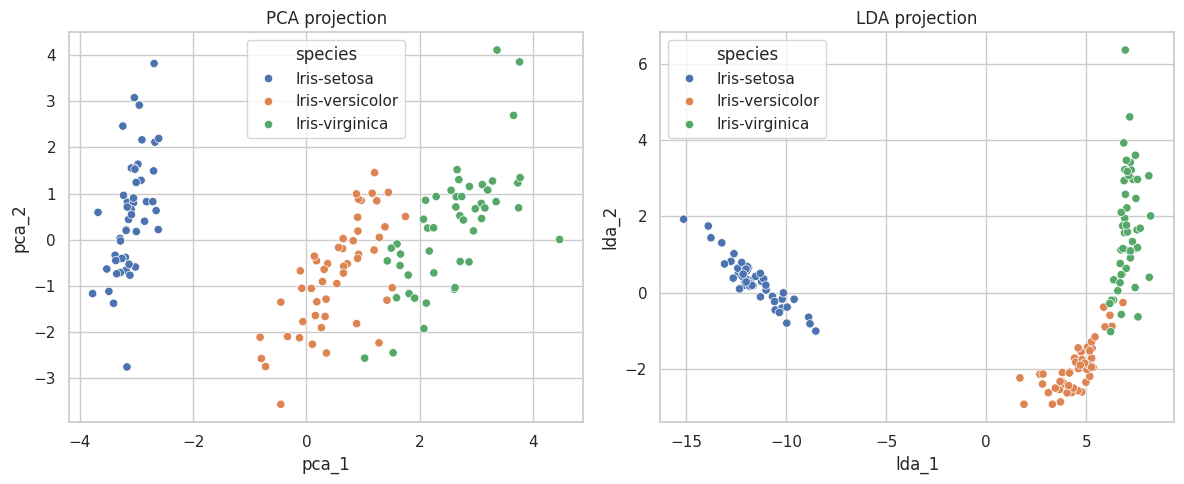

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=data, x="pca_1", y="pca_2", hue="species", ax=axes[0])
axes[0].set_title("PCA projection")
sns.scatterplot(data=data, x="lda_1", y="lda_2", hue="species", ax=axes[1])
axes[1].set_title("LDA projection")
fig.tight_layout()

The PCA projection reproduces what we already saw: setosa well apart from the other two, and versicolor/virginica adjacent with some overlap in the projected 2D space. The LDA projection separates all three species almost perfectly, which is expected given that it was fit using the species labels; it does not mean a classifier trained on the same features would do this well, only that a supervised, class-aware linear projection can separate this particular dataset well. This is a useful reminder to keep in mind when comparing PCA-based visualizations against classifier performance in the next notebook: the two are not directly comparable.

## Save outputs

The engineered and scaled feature matrix, along with the 2D projections, are saved to disk so the modeling notebook can load them directly without repeating this preprocessing.

In [11]:
data.to_parquet("../data/processed/data.parquet", index=False)

features_matrix = pd.concat([scaled, data[["species"]]], axis=1)
features_matrix.to_parquet("../data/processed/features.parquet", index=False)

features_matrix.head()

,sepal_length,sepal_width,petal_length,petal_width,sepal_area,petal_area,petal_sepal_length_ratio,petal_sepal_width_ratio,species
0,-0.900681,1.032057,-1.341272,-1.312977,0.012946,-1.173566,-1.434116,-1.355671,Iris-setosa
1,-1.143017,-0.124958,-1.341272,-1.312977,-0.925267,-1.173566,-1.387365,-1.319241,Iris-setosa
2,-1.385353,0.337848,-1.398138,-1.312977,-0.824000,-1.177823,-1.425412,-1.335179,Iris-setosa
3,-1.506521,0.106445,-1.284407,-1.312977,-1.056319,-1.169309,-1.218908,-1.327467,Iris-setosa
4,-1.021849,1.263460,-1.341272,-1.312977,0.057623,-1.173566,-1.411208,-1.361743,Iris-setosa


## Closing remarks

This EDA leaves us with a clear picture: setosa is essentially separable from the other two species on almost any feature, while versicolor and virginica overlap enough that no single feature, engineered or raw, cleanly separates them. The four raw measurements, four engineered features, and the class balance found here are the assumptions the next notebook builds on.

In the [next notebook](02_modeling_and_evaluation.ipynb), we compare several classifiers using cross-validation, given how few rows there are, and use confusion matrices and 2D decision boundaries to check whether the versicolor/virginica overlap identified here shows up as the main source of prediction error.